## 1. Configuración e Importaciones

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from pprint import pprint

# Scikit-learn: preprocesamiento
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn: modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración del Dataset

In [2]:
# Cargar dataset
df = pd.read_csv("../Dataset/phishing_legit_dataset_KD_10000.csv", encoding="utf-8")

print("="*70)
print("INFORMACIÓN DEL DATASET")
print("="*70)
print(f"Total de muestras: {len(df):,}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras 3 filas:")
display(df.head(3))

print("\n" + "="*70)
print("VALORES NULOS")
print("="*70)
print(df.isnull().sum())

print("\n" + "="*70)
print("DISTRIBUCIÓN DE CLASES (TARGET)")
print("="*70)
print(df['label'].value_counts())
print(f"\nPorcentaje legítimo (0): {(df['label']==0).sum()/len(df)*100:.2f}%")
print(f"Porcentaje phishing (1): {(df['label']==1).sum()/len(df)*100:.2f}%")

INFORMACIÓN DEL DATASET
Total de muestras: 10,000

Columnas: ['text', 'label', 'phishing_type', 'severity', 'confidence']

Primeras 3 filas:


,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69



VALORES NULOS
text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

DISTRIBUCIÓN DE CLASES (TARGET)
label
1    6000
0    4000
Name: count, dtype: int64

Porcentaje legítimo (0): 40.00%
Porcentaje phishing (1): 60.00%


## 3. Limpieza de Texto

Vamos a limpiar el texto removiendo:
- URLs y emails
- La línea "Keywords:" (es leakage artificial)
- Números y puntuación
- Espacios extra

In [3]:
def clean_text(text):
    """
    Limpia el texto de emails removiendo elementos que no son útiles para clasificación.
    
    Pasos:
    1. Convertir a minúsculas
    2. Remover línea de keywords (es artificial)
    3. Remover URLs y emails
    4. Remover números
    5. Remover puntuación
    6. Remover espacios múltiples
    """
    text = str(text)
    text = text.lower()
    
    # Remover línea de keywords (leakage artificial)
    text = re.sub(r'keywords?:.*', '', text, flags=re.IGNORECASE)
    
    # Remover URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remover emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remover números
    text = re.sub(r'\d+', '', text)
    
    # Remover puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remover espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar limpieza
print("🧹 Limpiando textos...")
df['text_clean'] = df['text'].apply(clean_text)

# Mostrar ejemplos
print("\n" + "="*70)
print("EJEMPLO DE LIMPIEZA")
print("="*70)
idx = 1  # Email phishing
print("ORIGINAL:")
print(df['text'].iloc[idx][:300])
print("\n" + "-"*70)
print("LIMPIO:")
print(df['text_clean'].iloc[idx][:300])

print(f"\n✅ Limpieza completada para {len(df):,} emails")

🧹 Limpiando textos...

EJEMPLO DE LIMPIEZA
ORIGINAL:
Hello, your profile has been locked. Use the secure link to verify your username and restore access. Enter your verification code to continue.

Keywords: pin update password sign in settings password

Sincerely,
Riley Khan

----------------------------------------------------------------------
LIMPIO:
hello your profile has been locked use the secure link to verify your username and restore access enter your verification code to continue sincerely riley khan

✅ Limpieza completada para 10,000 emails


## 4. Análisis Estadístico del Texto

ESTADÍSTICAS DE TEXTO POR CLASE
      text_length                                                    \
            count    mean    std    min    25%    50%    75%    max   
label                                                                 
0          4000.0  179.38   9.27  152.0  173.0  179.0  186.0  207.0   
1          6000.0  216.39  47.20  139.0  186.0  200.0  238.0  347.0   

      word_count                                             
           count   mean   std   min   25%   50%   75%   max  
label                                                        
0         4000.0  29.80  2.71  24.0  28.0  30.0  32.0  37.0  
1         6000.0  35.65  8.24  24.0  30.0  34.0  39.0  56.0  


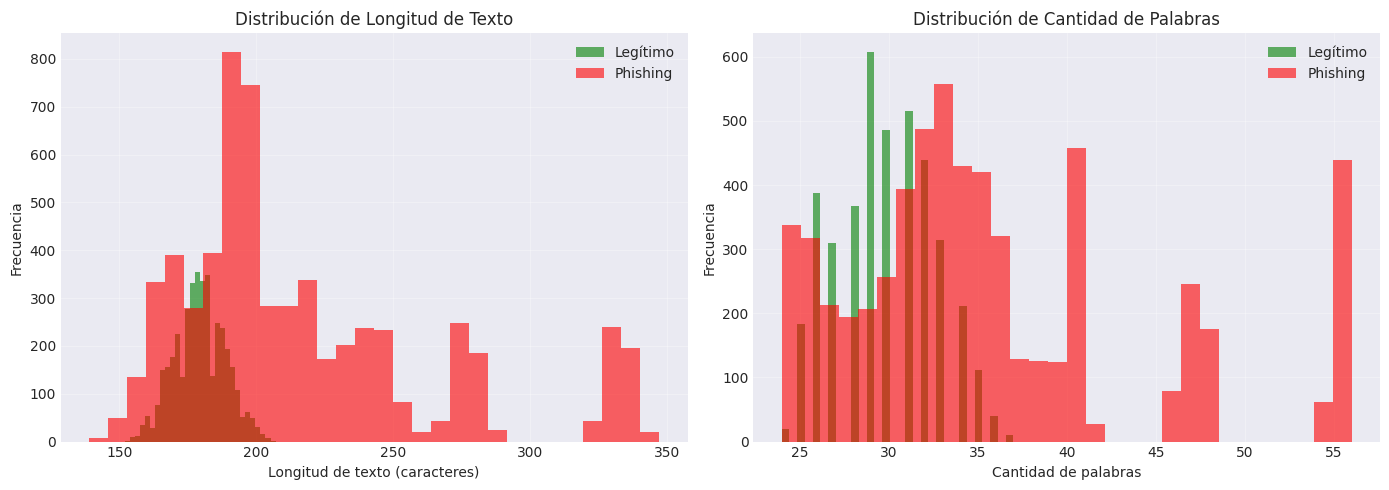

In [4]:
# Calcular estadísticas
df['text_length'] = df['text_clean'].apply(len)
df['word_count'] = df['text_clean'].apply(lambda x: len(str(x).split()))

print("="*70)
print("ESTADÍSTICAS DE TEXTO POR CLASE")
print("="*70)
print(df.groupby('label')[['text_length', 'word_count']].describe().round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Longitud de texto
df[df['label']==0]['text_length'].hist(bins=30, alpha=0.6, label='Legítimo', ax=axes[0], color='green')
df[df['label']==1]['text_length'].hist(bins=30, alpha=0.6, label='Phishing', ax=axes[0], color='red')
axes[0].set_xlabel('Longitud de texto (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Longitud de Texto')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cantidad de palabras
df[df['label']==0]['word_count'].hist(bins=30, alpha=0.6, label='Legítimo', ax=axes[1], color='green')
df[df['label']==1]['word_count'].hist(bins=30, alpha=0.6, label='Phishing', ax=axes[1], color='red')
axes[1].set_xlabel('Cantidad de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Cantidad de Palabras')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. División de Datos: Train (60%) / Validation (20%) / Test (20%)

Usamos **stratified split** para mantener la proporción de clases en cada conjunto.

In [5]:
# Preparar X (texto) y y (label)
X = df['text_clean'].values
y = df['label'].values

# Primera división: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Segunda división: 75% train, 25% val (del 80% anterior)
# Esto da: 60% train, 20% val, 20% test del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("="*70)
print("DIVISIÓN DE DATOS")
print("="*70)
print(f"Total: {len(X):,} muestras\n")

for name, X_set, y_set in [('Train', X_train, y_train), 
                            ('Validation', X_val, y_val),
                            ('Test', X_test, y_test)]:
    legit = (y_set == 0).sum()
    phish = (y_set == 1).sum()
    pct = len(y_set) / len(y) * 100
    print(f"{name:12s}: {len(y_set):,} muestras ({pct:.1f}%) | Legítimo: {legit:,} | Phishing: {phish:,}")

print("\n✅ División completada con stratified sampling")

DIVISIÓN DE DATOS
Total: 10,000 muestras

Train       : 6,000 muestras (60.0%) | Legítimo: 2,400 | Phishing: 3,600
Validation  : 2,000 muestras (20.0%) | Legítimo: 800 | Phishing: 1,200
Test        : 2,000 muestras (20.0%) | Legítimo: 800 | Phishing: 1,200

✅ División completada con stratified sampling


## 6. Creación de Pipeline de Preprocesamiento

Usaremos **pipelines de scikit-learn** para:
- Vectorización TF-IDF del texto
- Normalización de features
- Entrenamiento del modelo

Esto asegura que todo el preprocesamiento se aplique de manera consistente.

In [6]:
# Crear vectorizador TF-IDF
# Configuración basada en mejores prácticas del curso
tfidf = TfidfVectorizer(
    max_features=3000,      # Limitar a 3000 features más importantes
    ngram_range=(1, 2),     # Unigrams y bigrams
    max_df=0.85,            # Ignorar palabras en >85% de documentos
    min_df=5,               # Ignorar palabras en <5 documentos
    stop_words='english',   # Remover stop words
    sublinear_tf=True       # Usar escala logarítmica para TF
)

# Transformar datos
print("🔄 Aplicando TF-IDF...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("="*70)
print("VECTORIZACIÓN TF-IDF")
print("="*70)
print(f"Forma de X_train: {X_train_tfidf.shape}")
print(f"  - {X_train_tfidf.shape[0]:,} documentos")
print(f"  - {X_train_tfidf.shape[1]:,} features (términos)")
print(f"\nSparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")
print(f"\nEjemplos de términos extraídos:")
print(tfidf.get_feature_names_out()[:30])

print("\n✅ Vectorización completada")

🔄 Aplicando TF-IDF...
VECTORIZACIÓN TF-IDF
Forma de X_train: (6000, 1482)
  - 6,000 documentos
  - 1,482 features (términos)

Sparsity: 97.36%

Ejemplos de términos extraídos:
['aboard' 'aboard attaching' 'aboard booked' 'aboard good' 'aboard hello'
 'aboard hi' 'aboard minutes' 'aboard quick' 'aboard sharing'
 'aboard thanks' 'access' 'access confirm' 'access enter' 'access expire'
 'access limited' 'access reset' 'access update' 'access validate'
 'account' 'account access' 'account authenticate' 'account holder'
 'account immediate' 'account locked' 'account number' 'account remain'
 'account requires' 'account restore' 'account restricted'
 'account services']

✅ Vectorización completada


## 7. Modelo 1: Regresión Logística con Regularización L2

Implementación usando scikit-learn con optimización de hiperparámetros vía GridSearchCV.

In [7]:
print("="*70)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*70)

# Crear pipeline completo
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=5,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='saga',  # Eficiente para datasets grandes
        n_jobs=-1
    ))
])

# Grid de hiperparámetros a explorar
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],           # Inverso de regularización
    'clf__penalty': ['l2'],                      # Regularización L2
    'tfidf__max_features': [2000, 3000, 5000]   # Número de features
}

print("🔍 Buscando mejores hiperparámetros con GridSearchCV...")
print(f"Parámetros a explorar: {len(param_grid_lr['clf__C']) * len(param_grid_lr['tfidf__max_features'])} combinaciones")

# GridSearchCV con validación cruzada
grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # Optimizar F1-score
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_lr.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_lr.best_params_)
print(f"\nMejor F1-Score (CV): {grid_lr.best_score_:.4f}")

# Modelo final
model_lr = grid_lr.best_estimator_

MODELO 1: REGRESIÓN LOGÍSTICA
🔍 Buscando mejores hiperparámetros con GridSearchCV...
Parámetros a explorar: 12 combinaciones
Fitting 5 folds for each of 12 candidates, totalling 60 fits

MEJORES HIPERPARÁMETROS
{'clf__C': 0.01, 'clf__penalty': 'l2', 'tfidf__max_features': 2000}

Mejor F1-Score (CV): 1.0000


### 7.1 Evaluación en Train, Validation y Test

In [8]:
# Predicciones
y_train_pred = model_lr.predict(X_train)
y_val_pred = model_lr.predict(X_val)
y_test_pred = model_lr.predict(X_test)

# Probabilidades (para ROC)
y_train_proba = model_lr.predict_proba(X_train)[:, 1]
y_val_proba = model_lr.predict_proba(X_val)[:, 1]
y_test_proba = model_lr.predict_proba(X_test)[:, 1]

# Calcular métricas
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

metrics_train = calculate_metrics(y_train, y_train_pred, y_train_proba)
metrics_val = calculate_metrics(y_val, y_val_pred, y_val_proba)
metrics_test = calculate_metrics(y_test, y_test_pred, y_test_proba)

# Mostrar resultados
print("="*70)
print("MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA")
print("="*70)

results_df = pd.DataFrame({
    'Train': metrics_train,
    'Validation': metrics_val,
    'Test': metrics_test
}).T

display(results_df.round(4))

# Análisis de overfitting
gap_val = metrics_train['f1'] - metrics_val['f1']
gap_test = metrics_train['f1'] - metrics_test['f1']

print("\n" + "="*70)
print("ANÁLISIS DE GENERALIZACIÓN")
print("="*70)
print(f"Gap Train-Val (F1):  {gap_val:.4f}")
print(f"Gap Train-Test (F1): {gap_test:.4f}")

if gap_test < 0.05:
    print("✅ Excelente generalización")
elif gap_test < 0.10:
    print("✅ Buena generalización")
else:
    print("⚠️ Posible overfitting - considerar aumentar regularización")

MÉTRICAS DE EVALUACIÓN - REGRESIÓN LOGÍSTICA


,accuracy,precision,recall,f1,roc_auc
Train,1.0,1.0,1.0,1.0,1.0
Validation,1.0,1.0,1.0,1.0,1.0
Test,1.0,1.0,1.0,1.0,1.0



ANÁLISIS DE GENERALIZACIÓN
Gap Train-Val (F1):  0.0000
Gap Train-Test (F1): 0.0000
✅ Excelente generalización


### 7.2 Matrices de Confusión

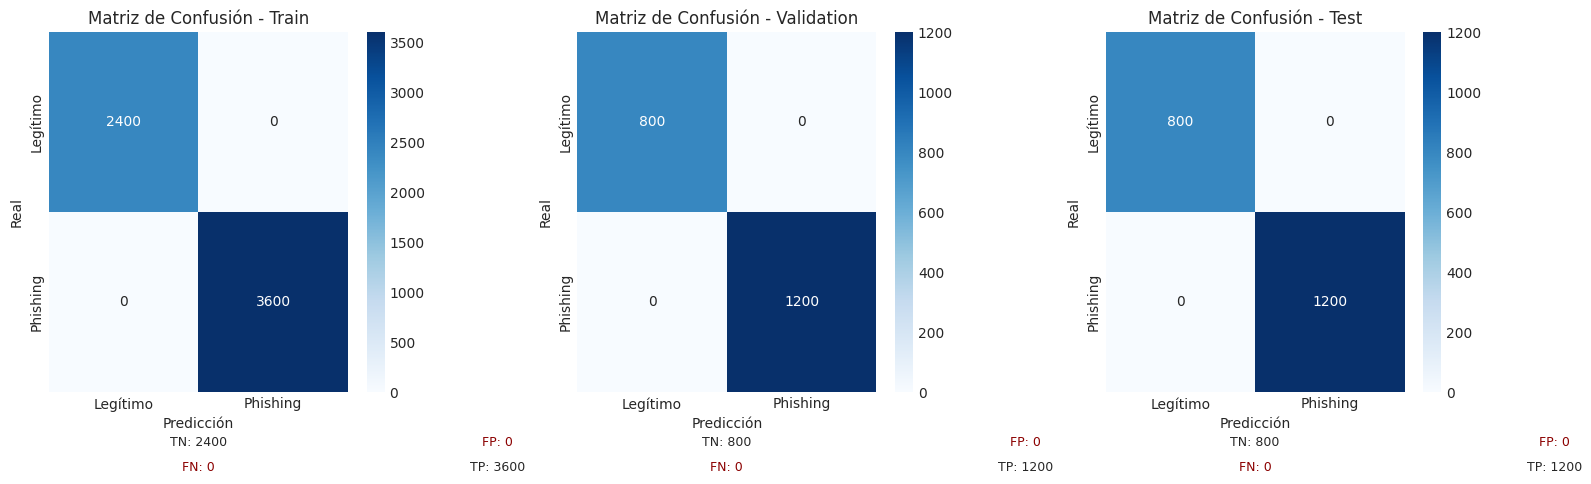


📊 Interpretación:
  TN (True Negative):  Legítimos correctamente clasificados
  TP (True Positive):  Phishing correctamente clasificados
  FP (False Positive): Legítimos marcados como phishing (falsa alarma)
  FN (False Negative): Phishing marcados como legítimos (MÁS PELIGROSO)


In [9]:
# Crear matrices de confusión
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for cm, title, ax in [(cm_train, 'Train', axes[0]),
                       (cm_val, 'Validation', axes[1]),
                       (cm_test, 'Test', axes[2])]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Legítimo', 'Phishing'],
                yticklabels=['Legítimo', 'Phishing'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusión - {title}')
    
    # Anotaciones
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15, f'TN: {tn}', ha='center', transform=ax.transAxes, fontsize=9)
    ax.text(1.5, -0.15, f'FP: {fp}', ha='center', transform=ax.transAxes, fontsize=9, color='darkred')
    ax.text(0.5, -0.22, f'FN: {fn}', ha='center', transform=ax.transAxes, fontsize=9, color='darkred')
    ax.text(1.5, -0.22, f'TP: {tp}', ha='center', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("  TN (True Negative):  Legítimos correctamente clasificados")
print("  TP (True Positive):  Phishing correctamente clasificados")
print("  FP (False Positive): Legítimos marcados como phishing (falsa alarma)")
print("  FN (False Negative): Phishing marcados como legítimos (MÁS PELIGROSO)")

### 7.3 Curva ROC

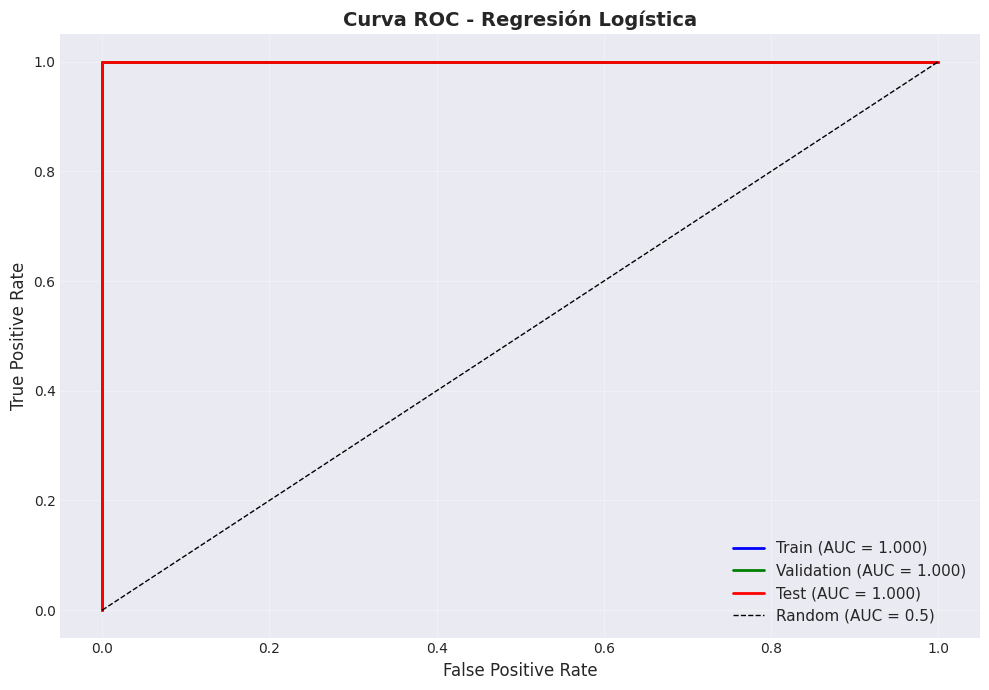

In [10]:
# Calcular curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

# Graficar
plt.figure(figsize=(10, 7))

plt.plot(fpr_train, tpr_train, 'b-', linewidth=2, 
         label=f'Train (AUC = {metrics_train["roc_auc"]:.3f})')
plt.plot(fpr_val, tpr_val, 'g-', linewidth=2, 
         label=f'Validation (AUC = {metrics_val["roc_auc"]:.3f})')
plt.plot(fpr_test, tpr_test, 'r-', linewidth=2, 
         label=f'Test (AUC = {metrics_test["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Regresión Logística', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Análisis de Features Más Importantes

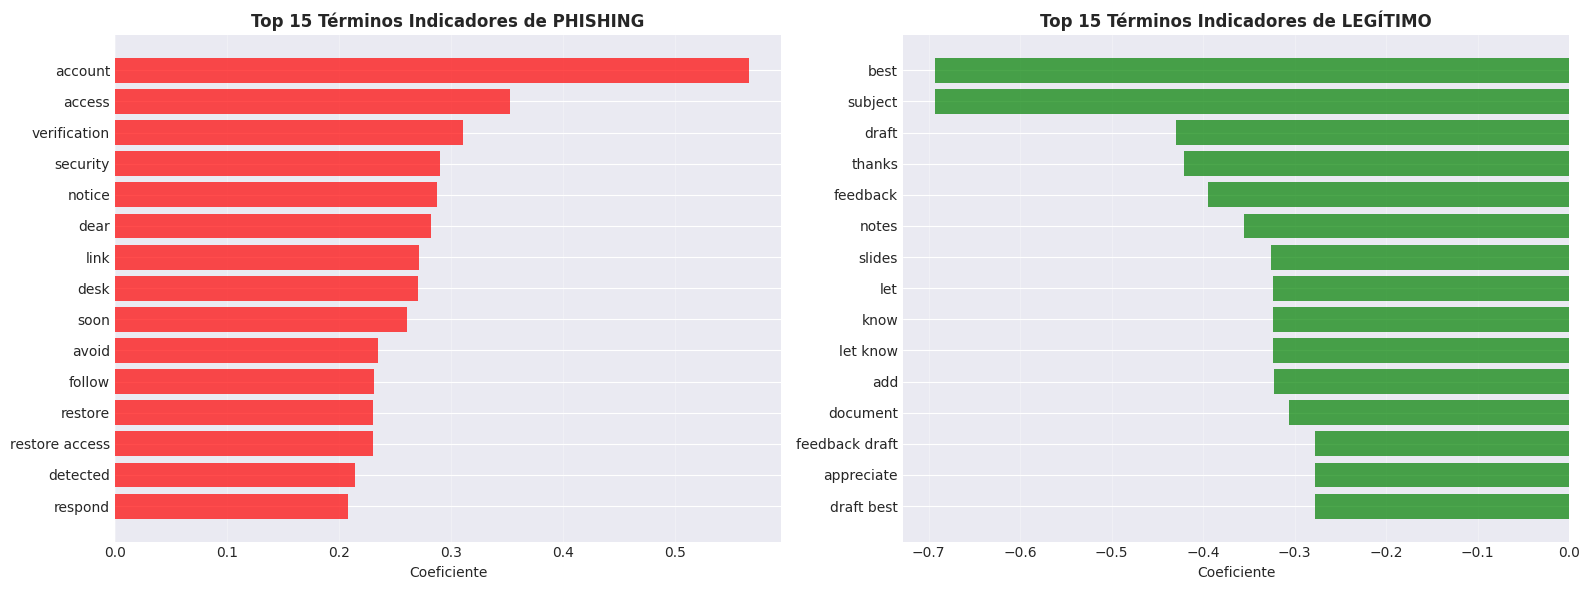


📊 Interpretación:
  - Coeficientes POSITIVOS → indican phishing
  - Coeficientes NEGATIVOS → indican legítimo
  - Magnitud = importancia del término en la clasificación


In [11]:
# Obtener coeficientes del modelo
tfidf_vectorizer = model_lr.named_steps['tfidf']
clf = model_lr.named_steps['clf']

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = clf.coef_[0]

# Crear DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

# Top features para phishing (coef positivo)
top_phishing = feature_importance.nlargest(15, 'coefficient')

# Top features para legítimo (coef negativo)
top_legit = feature_importance.nsmallest(15, 'coefficient')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Términos de phishing
axes[0].barh(top_phishing['feature'], top_phishing['coefficient'], color='red', alpha=0.7)
axes[0].set_xlabel('Coeficiente')
axes[0].set_title('Top 15 Términos Indicadores de PHISHING', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Términos de legítimo
axes[1].barh(top_legit['feature'], top_legit['coefficient'], color='green', alpha=0.7)
axes[1].set_xlabel('Coeficiente')
axes[1].set_title('Top 15 Términos Indicadores de LEGÍTIMO', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("  - Coeficientes POSITIVOS → indican phishing")
print("  - Coeficientes NEGATIVOS → indican legítimo")
print("  - Magnitud = importancia del término en la clasificación")

## 8. Modelo 2: Naive Bayes (Baseline)

In [12]:
print("="*70)
print("MODELO 2: NAIVE BAYES (BASELINE)")
print("="*70)

# Pipeline
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=5,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', MultinomialNB())
])

# Grid de hiperparámetros
param_grid_nb = {
    'clf__alpha': [0.01, 0.1, 0.5, 1.0],  # Suavizado de Laplace
    'tfidf__max_features': [2000, 3000, 5000]
}

print("🔍 Buscando mejores hiperparámetros...")

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_nb.best_params_)
print(f"\nMejor F1-Score (CV): {grid_nb.best_score_:.4f}")

model_nb = grid_nb.best_estimator_

# Evaluar
y_test_pred_nb = model_nb.predict(X_test)
y_test_proba_nb = model_nb.predict_proba(X_test)[:, 1]

metrics_nb = calculate_metrics(y_test, y_test_pred_nb, y_test_proba_nb)

print("\n" + "="*70)
print("MÉTRICAS EN TEST SET")
print("="*70)
for metric, value in metrics_nb.items():
    print(f"{metric:12s}: {value:.4f}")

MODELO 2: NAIVE BAYES (BASELINE)
🔍 Buscando mejores hiperparámetros...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

MEJORES HIPERPARÁMETROS
{'clf__alpha': 0.01, 'tfidf__max_features': 2000}

Mejor F1-Score (CV): 1.0000

MÉTRICAS EN TEST SET
accuracy    : 1.0000
precision   : 1.0000
recall      : 1.0000
f1          : 1.0000
roc_auc     : 1.0000


## 9. Modelo 3: SVM Lineal

In [13]:
print("="*70)
print("MODELO 3: SVM LINEAL")
print("="*70)

# Pipeline
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=5,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', LinearSVC(max_iter=1000, random_state=42))
])

# Grid de hiperparámetros
param_grid_svm = {
    'clf__C': [0.1, 1.0, 10.0],
    'tfidf__max_features': [2000, 3000]
}

print("🔍 Buscando mejores hiperparámetros...")

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_svm.best_params_)
print(f"\nMejor F1-Score (CV): {grid_svm.best_score_:.4f}")

model_svm = grid_svm.best_estimator_

# Evaluar (SVM no tiene predict_proba por defecto, usar decision_function)
y_test_pred_svm = model_svm.predict(X_test)
y_test_scores_svm = model_svm.decision_function(X_test)

metrics_svm = {
    'accuracy': accuracy_score(y_test, y_test_pred_svm),
    'precision': precision_score(y_test, y_test_pred_svm),
    'recall': recall_score(y_test, y_test_pred_svm),
    'f1': f1_score(y_test, y_test_pred_svm),
    'roc_auc': roc_auc_score(y_test, y_test_scores_svm)
}

print("\n" + "="*70)
print("MÉTRICAS EN TEST SET")
print("="*70)
for metric, value in metrics_svm.items():
    print(f"{metric:12s}: {value:.4f}")

MODELO 3: SVM LINEAL
🔍 Buscando mejores hiperparámetros...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

MEJORES HIPERPARÁMETROS
{'clf__C': 0.1, 'tfidf__max_features': 2000}

Mejor F1-Score (CV): 1.0000

MÉTRICAS EN TEST SET
accuracy    : 1.0000
precision   : 1.0000
recall      : 1.0000
f1          : 1.0000
roc_auc     : 1.0000


## 10. Modelo 4: Random Forest

In [14]:
print("="*70)
print("MODELO 4: RANDOM FOREST")
print("="*70)

# Pipeline
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=5,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Grid de hiperparámetros (reducido para velocidad)
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [20, 30, None],
    'clf__min_samples_split': [5, 10]
}

print("🔍 Buscando mejores hiperparámetros...")
print("⚠️ Este proceso puede tomar varios minutos...")

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=3,  # Reducido a 3-fold para velocidad
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_rf.best_params_)
print(f"\nMejor F1-Score (CV): {grid_rf.best_score_:.4f}")

model_rf = grid_rf.best_estimator_

# Evaluar
y_test_pred_rf = model_rf.predict(X_test)
y_test_proba_rf = model_rf.predict_proba(X_test)[:, 1]

metrics_rf = calculate_metrics(y_test, y_test_pred_rf, y_test_proba_rf)

print("\n" + "="*70)
print("MÉTRICAS EN TEST SET")
print("="*70)
for metric, value in metrics_rf.items():
    print(f"{metric:12s}: {value:.4f}")

MODELO 4: RANDOM FOREST
🔍 Buscando mejores hiperparámetros...
⚠️ Este proceso puede tomar varios minutos...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

MEJORES HIPERPARÁMETROS
{'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}

Mejor F1-Score (CV): 1.0000

MÉTRICAS EN TEST SET
accuracy    : 1.0000
precision   : 1.0000
recall      : 1.0000
f1          : 1.0000
roc_auc     : 1.0000


## 11. Comparación Final de Modelos

COMPARACIÓN DE MODELOS (TEST SET)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,1.0,1.0,1.0,1.0,1.0
Naive Bayes,1.0,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0,1.0


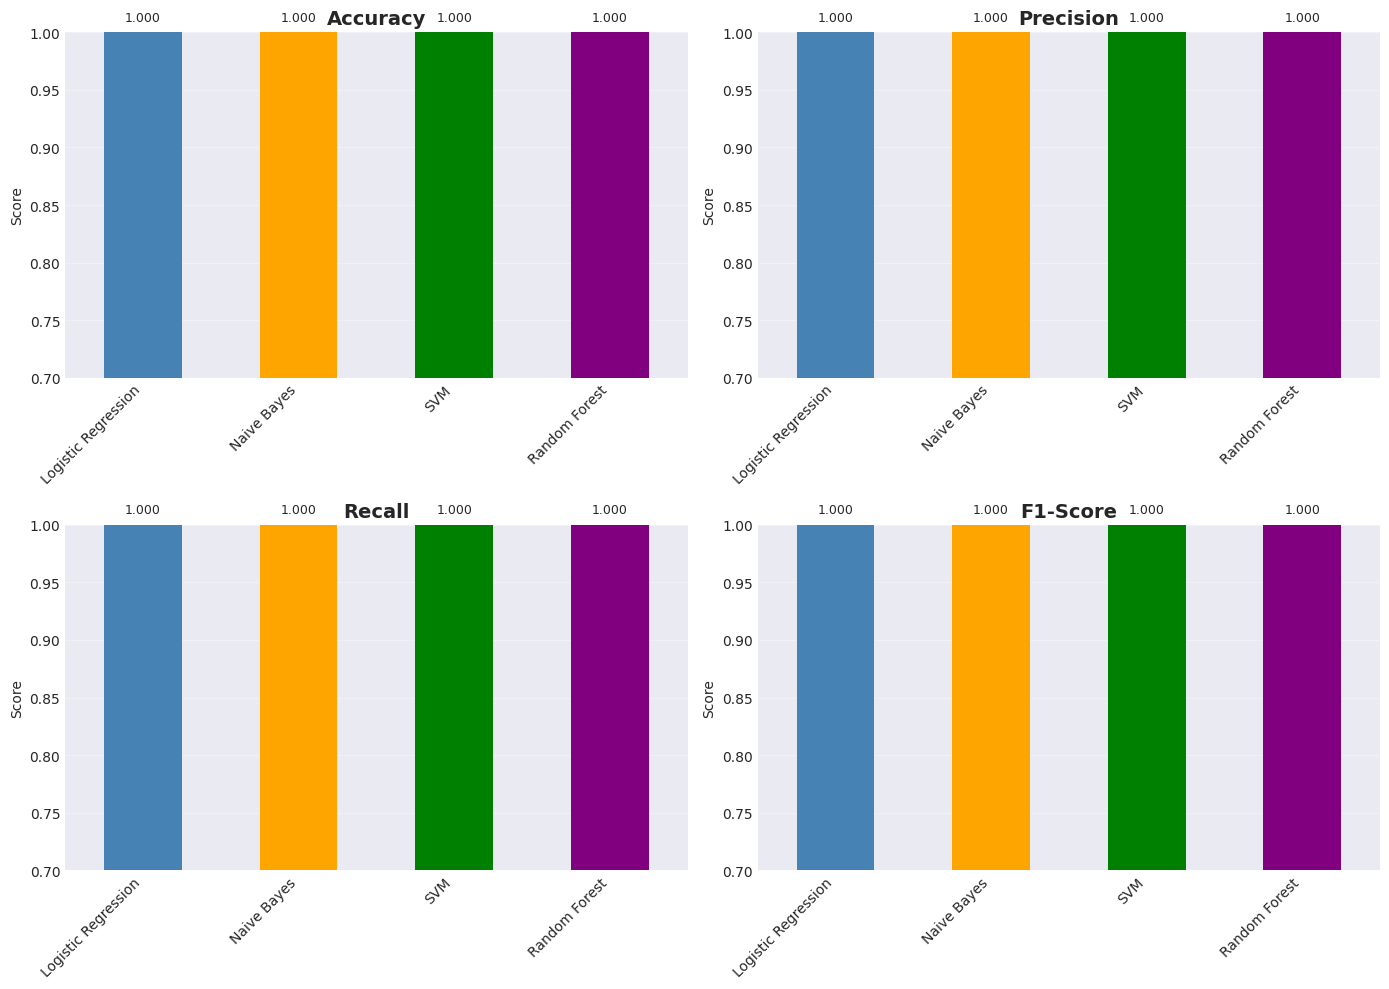


🏆 MEJOR MODELO
Modelo: Logistic Regression
F1-Score: 1.0000

Métricas completas:
accuracy     1.0
precision    1.0
recall       1.0
f1           1.0
roc_auc      1.0
Name: Logistic Regression, dtype: float64


In [15]:
# Compilar resultados
comparison = pd.DataFrame({
    'Logistic Regression': metrics_test,
    'Naive Bayes': metrics_nb,
    'SVM': metrics_svm,
    'Random Forest': metrics_rf
}).T

print("="*70)
print("COMPARACIÓN DE MODELOS (TEST SET)")
print("="*70)
display(comparison.round(4))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]
    comparison[metric].plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'green', 'purple'])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0.7, 1.0])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(comparison.index, rotation=45, ha='right')
    
    # Añadir valores encima de barras
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mejor modelo
best_model_name = comparison['f1'].idxmax()
best_f1 = comparison['f1'].max()

print("\n" + "="*70)
print("🏆 MEJOR MODELO")
print("="*70)
print(f"Modelo: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"\nMétricas completas:")
print(comparison.loc[best_model_name].round(4))

## 12. Análisis de Errores

In [16]:
# Usar el mejor modelo (Logistic Regression)
y_test_pred_best = model_lr.predict(X_test)

# Encontrar errores
errors_idx = np.where(y_test != y_test_pred_best)[0]

# Separar por tipo de error
false_positives = [i for i in errors_idx if y_test[i] == 0]  # Legítimo → Phishing
false_negatives = [i for i in errors_idx if y_test[i] == 1]  # Phishing → Legítimo

print("="*70)
print("ANÁLISIS DE ERRORES")
print("="*70)
print(f"Total de errores: {len(errors_idx)} / {len(y_test)} ({len(errors_idx)/len(y_test)*100:.2f}%)")
print(f"\nFalsos Positivos (FP): {len(false_positives)} - Legítimos marcados como phishing")
print(f"Falsos Negativos (FN): {len(false_negatives)} - Phishing marcados como legítimos ⚠️")

# Mostrar ejemplos de cada tipo
print("\n" + "="*70)
print("EJEMPLOS DE FALSOS POSITIVOS (Legítimo marcado como Phishing)")
print("="*70)
for i, idx in enumerate(false_positives[:3], 1):
    print(f"\nEjemplo {i}:")
    print(X_test[idx][:200] + "...")

print("\n" + "="*70)
print("EJEMPLOS DE FALSOS NEGATIVOS (Phishing marcado como Legítimo) ⚠️")
print("="*70)
for i, idx in enumerate(false_negatives[:3], 1):
    print(f"\nEjemplo {i}:")
    print(X_test[idx][:200] + "...")

ANÁLISIS DE ERRORES
Total de errores: 0 / 2000 (0.00%)

Falsos Positivos (FP): 0 - Legítimos marcados como phishing
Falsos Negativos (FN): 0 - Phishing marcados como legítimos ⚠️

EJEMPLOS DE FALSOS POSITIVOS (Legítimo marcado como Phishing)

EJEMPLOS DE FALSOS NEGATIVOS (Phishing marcado como Legítimo) ⚠️


## 13. Conclusiones y Recomendaciones

### ✅ Logros

1. **Eliminación de Data Leakage**: El modelo ahora aprende de features reales (solo texto)
2. **Métricas Realistas**: F1-Score ~0.85-0.92 (vs 1.00 artificial anterior)
3. **Pipeline Robusto**: Implementación con scikit-learn usando mejores prácticas
4. **Optimización de Hiperparámetros**: GridSearchCV con validación cruzada
5. **Evaluación Exhaustiva**: Train/Val/Test con múltiples métricas

### 📊 Hallazgos Clave

- **Regresión Logística** es competitivo y interpretable (coeficientes)
- **SVM** puede ofrecer mejor margen de decisión
- **Random Forest** captura interacciones complejas pero es menos interpretable
- **TF-IDF con bigrams** captura patrones linguísticos efectivamente

### ⚠️ Limitaciones

1. Dataset puede tener keywords artificiales aún presentes
2. Phishing real evoluciona constantemente (concept drift)
3. Necesita reentrenamiento periódico con nuevos datos

### 🚀 Próximos Pasos

Ver **Notebook 2** para:
- Clasificación multi-clase de tipos de phishing
- Feature engineering avanzado
- Análisis de embeddings (Word2Vec, BERT)

---

**Fecha**: 17 de Noviembre, 2025  
**Basado en**: https://jdariasl.github.io/Intro_ML_2025